# Synthetic Data Generation for Recipe RFT/SFT/DPO

**CIS 5270 Course Project — Team: Akshat, Rashi, Ritika**

This notebook implements the synthetic data generation pipeline

### Pipeline

```
L = []
N = 1000 - 5000
while len(L) <= N:
    (x)    1st LLM call: Generate random ingredients list (seeded with cuisine/meal-type)
    (y)    2nd LLM call: Using list, generate a constraint-satisfying student-friendly recipe
    (y')   3rd LLM call: Generate a negative recipe (constraint-violating) for DPO
    4th LLM call: LLM-as-judge to verify (x, y) sanity check
    if sanity_check_passed:
        L.append((x, y, y'))
```

### Outputs

The pipeline produces a single pool of `(x, y, y')` triples, which are then split into the JSONL files the Azure fine-tuning jobs expect:

- `sft_train.jsonl` / `sft_val.jsonl` — messages format, `(x, y)` only
- `dpo_train.jsonl` / `dpo_val.jsonl` — preference format, `(x, y, y')`
- `rft_train.jsonl` / `rft_val.jsonl` — prompts + reference (for the grader)

### Design choices

- **Ingredient generation**: hybrid seeding. We sample a `(cuisine, meal_type, difficulty_hint)` tuple and ask GPT-5-mini to produce a realistic ingredient list. This gives us diversity without hardcoding thousands of lists.
- **Preferred vs rejected**: generated in **separate calls** with different system prompts — the preferred prompt enforces constraints, the rejected prompt is explicitly instructed to violate one or more (e.g., ignore some ingredients, be long-winded, skip structure). Cleaner contrast for DPO than asking one call for both.
- **Sanity check**: the 4th call (LLM-as-judge) returns a structured JSON verdict. Only samples that pass are appended.
- **Robustness**: every LLM call is wrapped in retry-with-backoff, all outputs are validated as JSON before use, and the pipeline checkpoints to disk every N samples so a crash doesn't lose progress.
- **Concurrency**: uses `ThreadPoolExecutor` so the four sequential LLM calls per sample run in parallel across many samples. This is the dominant cost of the pipeline.

## 1. Setup and Azure client

Same auth block as the starter notebook — update `RESOURCE_GROUP` and `OPENAI_API_KEY` with your team's Gradescope credentials.

In [ ]:
%pip install -q openai azure-identity python-dotenv tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.7/91.7 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.1/192.1 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.3/218.3 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.5/121.5 kB 4.8 MB/s eta 0:00:00


In [ ]:

import os
import json
import time
import random
import hashlib
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import dataclass, asdict
from typing import Optional

from openai import AzureOpenAI
from tqdm.auto import tqdm

In [ ]:
%pip install -q \
  "azure-ai-projects>=2.0.0b1" \
  openai \
  azure-identity \
  azure-mgmt-cognitiveservices \
  "azure-ai-evaluation>=1.13.0" \
  python-dotenv

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.3/274.3 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.1/290.1 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 431.5/431.5 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 4.7 MB/s eta 0:00:00


In [ ]:
import os
from openai import AzureOpenAI
from azure.identity import DefaultAzureCredential
from azure.mgmt.cognitiveservices import CognitiveServicesManagementClient
from azure.mgmt.cognitiveservices.models import Deployment, DeploymentProperties, DeploymentModel, Sku

In [ ]:
RESOURCE_GROUP = 'cis-5270-team-14'
OPENAI_API_KEY = ''
OPENAI_ENDPOINT = f"https://{RESOURCE_GROUP}.openai.azure.com"
SUBSCRIPTION_ID = ''

openai_client = AzureOpenAI(
    api_key=OPENAI_API_KEY,
    azure_endpoint=OPENAI_ENDPOINT,
    api_version="2025-04-01-preview",
)

# Generator/judge model — the "stronger model" from the proposal.
# gpt-5-mini is the teacher; the student model we fine-tune is gpt-4.1-nano.
GENERATOR_MODEL = "gpt-4.1-mini"
JUDGE_MODEL = "gpt-4.1-mini"

print("Connected to Azure OpenAI")

Connected to Azure OpenAI


In [ ]:

# Azure resource targeting
os.environ["AZURE_SUBSCRIPTION_ID"] = SUBSCRIPTION_ID
os.environ["AZURE_RESOURCE_GROUP"] = 'CIS-5270'
os.environ["AZURE_AOAI_ACCOUNT"] = RESOURCE_GROUP
os.environ["AZURE_OPENAI_API_KEY"] = OPENAI_API_KEY
os.environ["AZURE_OPENAI_ENDPOINT"] = OPENAI_ENDPOINT
CREDENTIAL = DefaultAzureCredential()

## 2. Pipeline configuration

In [ ]:
@dataclass
class Config:
    # Target dataset size.
    n_samples: int = 2000

    # Train/val split.
    val_fraction: float = 0.20

    # Concurrency
    max_workers: int = 8

    # Retries per LLM call.
    max_retries: int = 4

    # Recipe constraints
    min_steps: int = 3
    max_steps: int = 7
    max_cook_minutes: int = 15

    # Checkpointing — flush the pool to disk every N accepted samples.
    checkpoint_every: int = 50

    # Output directory.
    out_dir: str = "data"

    # Reproducibility.
    seed: int = 42

CFG = Config()
Path(CFG.out_dir).mkdir(exist_ok=True)
random.seed(CFG.seed)
print(f"Target: {CFG.n_samples} samples -> {CFG.out_dir}/")

Target: 9000 samples -> data/


## 3. Seed pantry for hybrid ingredient generation

We don't hardcode ingredient lists — we hardcode *seeds* (cuisine, meal type, a hint or two) and let GPT-5-mini invent a plausible ingredient list. This gets us diversity cheaply without drifting into repetitive outputs the way free-form generation does.

In [ ]:
CUISINES = [
    "Italian", "Mexican", "Indian", "Chinese", "Thai", "American", "Korean", "Japanese", "French", "Spanish", "British"
]

MEAL_TYPES = [
    "breakfast", "lunch", "late-night snack", "dinner",
]

DIETARY_HINTS = [
    None, None,   # weight toward unrestricted
    "vegetarian", "vegan", "gluten-free",
]

def sample_seed(rng: random.Random) -> dict:
    return {
        "cuisine": rng.choice(CUISINES),
        "meal_type": rng.choice(MEAL_TYPES),
        "dietary": rng.choice(DIETARY_HINTS),
        "n_ingredients": rng.randint(3, 7),
    }

# Preview
_preview_rng = random.Random(0)
for _ in range(5):
    print(sample_seed(_preview_rng))

{'cuisine': 'Korean', 'meal_type': 'dinner', 'dietary': None, 'n_ingredients': 5}
{'cuisine': 'French', 'meal_type': 'dinner', 'dietary': 'vegan', 'n_ingredients': 5}
{'cuisine': 'Japanese', 'meal_type': 'late-night snack', 'dietary': 'gluten-free', 'n_ingredients': 4}
{'cuisine': 'French', 'meal_type': 'lunch', 'dietary': 'vegetarian', 'n_ingredients': 4}
{'cuisine': 'Mexican', 'meal_type': 'late-night snack', 'dietary': 'gluten-free', 'n_ingredients': 7}


## 4. Robust LLM call helper

Every call in the pipeline needs retries and JSON validation. Wrap it once.

In [ ]:
def llm_json(
    system: str,
    user: str,
    model: str = GENERATOR_MODEL,
    max_retries: int = CFG.max_retries,
) -> Optional[dict]:
    """Call the LLM, expect a JSON object back, retry on errors/bad JSON."""
    for attempt in range(max_retries):
        try:
            resp = openai_client.chat.completions.create(
                model=model,
                messages=[
                    {"role": "system", "content": system},
                    {"role": "user", "content": user},
                ],
                response_format={"type": "json_object"},
            )
            content = resp.choices[0].message.content
            return json.loads(content)
        except json.JSONDecodeError as e:
            # Bad JSON - retry, the model sometimes wraps in code fences.
            if attempt == max_retries - 1:
                print(f"[warn] JSON parse failed after {max_retries} tries: {e}")
                return None
        except Exception as e:
            # Rate limit, transient network, etc. Exponential backoff.
            wait = (2 ** attempt) + random.random()
            if attempt == max_retries - 1:
                print(f"[warn] LLM call failed after {max_retries} tries: {e}")
                return None
            time.sleep(wait)
    return None

## 5. The four LLM calls

### Call 1 — Generate ingredient list `x`

Given a seed, produce a realistic ingredient list. We return structured JSON so downstream calls and the reward function can parse it reliably.

In [ ]:
INGREDIENTS_SYSTEM = """You generate realistic ingredient lists that a college student might have on hand.

Rules:
- Return ONLY a JSON object with keys: "ingredients" (list of strings) and "context" (short string).
- Each ingredient is a plain, lowercase name (e.g., "eggs", "bread", "soy sauce"). No quantities.
- Include common pantry staples the student would reasonably have.
- The list should be coherent with the cuisine and meal type hint.
- "context" is a one-line description of the scenario (e.g., "quick Italian breakfast from pantry").
"""

def generate_ingredients(seed: dict) -> Optional[dict]:
    user = f"""Generate an ingredient list for this scenario:
- cuisine: {seed['cuisine']}
- meal type: {seed['meal_type']}
- dietary hint: {seed['dietary'] or 'none'}
- number of ingredients: {seed['n_ingredients']}

Return JSON: {{"ingredients": [...], "context": "..."}}"""
    result = llm_json(INGREDIENTS_SYSTEM, user)
    if result is None or "ingredients" not in result:
        return None
    # Minimal validation.
    ings = result["ingredients"]
    if not isinstance(ings, list) or len(ings) < 2:
        return None
    result["ingredients"] = [str(i).strip().lower() for i in ings if i]
    result["seed"] = seed
    return result

### Call 2 — Generate preferred recipe `y`

Given the ingredient list, produce a recipe that *satisfies* all the constraints: uses the provided ingredients, is quick, has clear step-by-step structure, and is student-friendly. This is what SFT will teach the student model to imitate.

In [ ]:
PREFERRED_SYSTEM = f"""You are a recipe writer for busy college students.

You will be given a list of ingredients. Generate a recipe that strictly satisfies ALL of these constraints:

1. **Ingredient discipline**: Use ONLY ingredients from the provided list, plus water, salt, pepper, and cooking oil. Do not introduce unrelated ingredients.
2. **Speed**: Total time (prep + cook) must be {CFG.max_cook_minutes} minutes or less.
3. **Simplicity**: Between {CFG.min_steps} and {CFG.max_steps} steps. No step should require specialty equipment.
4. **Structure**: Each step is a single clear imperative sentence.
5. **Student-friendly**: Assume a tiny kitchen (stovetop, microwave, basic knife). No unusual techniques.

Return ONLY a JSON object with this exact shape:
{{
  "title": "...",
  "ingredients": ["...", "...", ....],
  "total_time_minutes": <int>,
  "steps": ["...", "...", ...]
}}
"""

def generate_preferred_recipe(ingredients: list[str], context: str) -> Optional[dict]:
    user = f"""Ingredients available: {', '.join(ingredients)}
Context: {context}

Write the recipe as JSON."""
    result = llm_json(PREFERRED_SYSTEM, user)
    if result is None:
        return None
    # Shape check.
    if not all(k in result for k in ("title", "total_time_minutes", "steps")):
        return None
    if not isinstance(result["steps"], list) or len(result["steps"]) == 0:
        return None
    return result

### Call 3 — Generate rejected recipe `y'`

For DPO we need a recipe that's *plausibly tempting but worse*. We pick a random failure mode and instruct the LLM to commit that specific violation. This produces sharper preference signal than asking for "a bad recipe" (which gives us obviously broken outputs that DPO learns little from).

In [ ]:
REJECTION_MODES = [
    {
        "name": "extra_ingredients",
        "instruction": "Add 2-3 ingredients that were NOT in the provided list (e.g., specialty items the student probably doesn't have). Otherwise the recipe should look reasonable.",
    },
    {
        "name": "too_long",
        "instruction": f"Make the recipe take much longer than {CFG.max_cook_minutes + 15} minutes (e.g., 30-60 minutes of cooking, marinating, or resting).",
    },
    {
        "name": "too_many_steps",
        "instruction": f"Write {CFG.max_steps + 5} or more steps. Be overly detailed and break simple actions into multiple micro-steps.",
    },
    {
        "name": "unsafe_equipment",
        "instruction": "Require specialty equipment a student wouldn't have.",
    },
]

REJECTED_SYSTEM_TEMPLATE = """You are writing an intentionally sub-optimal recipe for a preference-learning dataset.

You will be given an ingredient list. The recipe you produce MUST violate this specific constraint:

>> {mode_instruction}

Do NOT announce that the recipe is bad. Write it as if it were a real recipe. It should look reasonable on the surface.
The other constraints may be satisfied or not — only the one above is required to be violated.

Return ONLY a JSON object with this exact shape (same shape as a normal recipe):
{{
  "title": "...",
  "ingredients": ["...", "...", ...],
  "total_time_minutes": <int>,
  "steps": ["...", "...", ...]
}}
"""

def generate_rejected_recipe(ingredients: list[str], context: str, rng: random.Random) -> Optional[dict]:
    mode = rng.choice(REJECTION_MODES)
    system = REJECTED_SYSTEM_TEMPLATE.format(mode_instruction=mode["instruction"])
    user = f"""Ingredients available: {', '.join(ingredients)}
Context: {context}

Write the recipe as JSON. Remember to violate the specified constraint."""
    result = llm_json(system, user)
    if result is None:
        return None
    if not all(k in result for k in ("title", "total_time_minutes", "steps")):
        return None
    # Tag the failure mode so we can audit the dataset later.
    result["_rejection_mode"] = mode["name"]
    return result

### Call 4 — LLM-as-judge sanity check

The judge gets the ingredient list and the preferred recipe, and checks:
- Does the recipe use the provided ingredients (and not invent new ones)?
- Is it actually student-friendly (time, simplicity, structure)?
- Is the JSON well-formed semantically (e.g., `total_time_minutes` is plausible)?

We drop any sample the judge rejects.

In [ ]:
JUDGE_SYSTEM = f"""You are a strict evaluator verifying a recipe dataset.

You will see (1) an ingredient list and (2) a recipe. Check ALL of these:

1. ingredient_compliance: The recipe uses only ingredients from the list, plus water/salt/pepper/oil.
2. time_ok: total_time_minutes <= {CFG.max_cook_minutes} AND is plausible given the steps.
3. steps_ok: between {CFG.min_steps} and {CFG.max_steps} steps, each a clear single instruction.
4. student_friendly: no specialty equipment, realistic for a dorm kitchen.
5. coherent: the recipe actually makes a reasonable dish from these ingredients (not random word salad).

Return ONLY JSON:
{{
  "ingredient_compliance": <bool>,
  "time_ok": <bool>,
  "steps_ok": <bool>,
  "student_friendly": <bool>,
  "coherent": <bool>,
  "pass": <bool>,
  "reason": "<short explanation if pass is false, else empty>"
}}

Set "pass" to true only if ALL five checks are true.
"""

def judge_sample(ingredients: list[str], recipe: dict) -> Optional[dict]:
    user = f"""Ingredient list: {', '.join(ingredients)}

Recipe:
{json.dumps(recipe, indent=2)}

Evaluate and return JSON."""
    result = llm_json(JUDGE_SYSTEM, user, model=JUDGE_MODEL)
    if result is None or "pass" not in result:
        return None
    return result

## 6. Per-sample pipeline

In [ ]:
def generate_one_sample(sample_id: int, rng: random.Random) -> Optional[dict]:
    """Run the 4-call pipeline for one sample. Returns the sample dict or None if rejected."""
    # Call 1: ingredients.
    seed = sample_seed(rng)
    ing_result = generate_ingredients(seed)
    if ing_result is None:
        return None
    ingredients = ing_result["ingredients"]
    context = ing_result["context"]

    # Call 2: preferred recipe.
    preferred = generate_preferred_recipe(ingredients, context)
    if preferred is None:
        return None

    # Call 3: rejected recipe (runs independently of call 2).
    rejected = generate_rejected_recipe(ingredients, context, rng)
    if rejected is None:
        return None

    # Call 4: judge the preferred recipe.
    verdict = judge_sample(ingredients, preferred)
    if verdict is None or not verdict.get("pass", False):
        return None

    return {
        "id": sample_id,
        "seed": seed,
        "ingredients": ingredients,
        "context": context,
        "preferred": preferred,
        "rejected": rejected,
        "verdict": verdict,
    }

## 7. Run the pipeline

Parallel across samples.

In [ ]:
def checkpoint(pool: list[dict], path: str):
    """Flush the current pool to a single JSONL file so we don't lose progress."""
    with open(path, "w") as f:
        for s in pool:
            f.write(json.dumps(s) + "\n")

def load_checkpoint(path: str) -> list[dict]:
    if not Path(path).exists():
        return []
    with open(path) as f:
        return [json.loads(line) for line in f]

def run_pipeline(cfg: Config) -> list[dict]:
    ckpt_path = f"{cfg.out_dir}/pool.jsonl"
    pool = load_checkpoint(ckpt_path)
    if pool:
        print(f"Resuming from checkpoint: {len(pool)} samples already generated.")

    master_rng = random.Random(cfg.seed)
    n_submitted = len(pool)
    n_rejected = 0

    pbar = tqdm(total=cfg.n_samples, initial=len(pool), desc="accepted")

    with ThreadPoolExecutor(max_workers=cfg.max_workers) as ex:
        # Prime the pump.
        futures = set()
        def submit_one():
            nonlocal n_submitted
            worker_rng = random.Random(master_rng.random())
            fut = ex.submit(generate_one_sample, n_submitted, worker_rng)
            futures.add(fut)
            n_submitted += 1

        for _ in range(min(cfg.max_workers * 2, cfg.n_samples - len(pool))):
            submit_one()

        while len(pool) < cfg.n_samples and futures:
            done = next(as_completed(futures))
            futures.remove(done)
            try:
                sample = done.result()
            except Exception as e:
                print(f"[error] worker raised: {e}")
                sample = None

            if sample is not None:
                pool.append(sample)
                pbar.update(1)
                pbar.set_postfix(rejected=n_rejected, accept_rate=f"{len(pool)/(len(pool)+n_rejected):.2f}")
                if len(pool) % cfg.checkpoint_every == 0:
                    checkpoint(pool, ckpt_path)
            else:
                n_rejected += 1

            # Keep the queue fed as long as we still need samples.
            if len(pool) + len(futures) < cfg.n_samples:
                submit_one()

    pbar.close()
    checkpoint(pool, ckpt_path)
    print(f"\nDone. Accepted: {len(pool)}  Rejected: {n_rejected}  Acceptance rate: {len(pool)/(len(pool)+n_rejected):.1%}")
    return pool

In [ ]:

pool = run_pipeline(CFG)

accepted:   0%|          | 0/9000 [00:00<?, ?it/s]

[warn] LLM call failed after 4 tries: Error code: 400 - {'error': {'message': "The response was filtered due to the prompt triggering Azure OpenAI's content management policy. Please modify your prompt and retry. To learn more about our content filtering policies please read our documentation: https://go.microsoft.com/fwlink/?linkid=2198766", 'type': None, 'param': 'prompt', 'code': 'content_filter', 'status': 400, 'innererror': {'code': 'ResponsibleAIPolicyViolation', 'content_filter_result': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'detected': True, 'filtered': True}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}}}
[warn] LLM call failed after 4 tries: Error code: 400 - {'error': {'message': "The response was filtered due to the prompt triggering Azure OpenAI's content management policy. Please modify your prompt and retry. To learn more about our co

## 8. Quick sanity check on the pool

Before we split into SFT/DPO/RFT files, spot-check distribution and content.

In [ ]:
from collections import Counter

print(f"Pool size: {len(pool)}")
print(f"\nCuisine distribution:")
for cuisine, count in Counter(s['seed']['cuisine'] for s in pool).most_common():
    print(f"  {cuisine:20s} {count}")

print(f"\nRejection-mode distribution (in y'):")
for mode, count in Counter(s['rejected'].get('_rejection_mode', '?') for s in pool).most_common():
    print(f"  {mode:20s} {count}")

print(f"\nRecipe length (preferred):")
step_counts = [len(s['preferred']['steps']) for s in pool]
print(f"  mean steps: {sum(step_counts)/len(step_counts):.2f}")
print(f"  min/max:    {min(step_counts)} / {max(step_counts)}")

print(f"\nSample example:")
print(json.dumps(pool[0], indent=2)[:1500])

Pool size: 2000

Cuisine distribution:
  Mexican              250
  Italian              233
  Spanish              223
  American             214
  Korean               213
  British              189
  Chinese              180
  French               176
  Thai                 172
  Indian               91
  Japanese             59

Rejection-mode distribution (in y'):
  unsafe_equipment     539
  too_long             494
  too_many_steps       493
  extra_ingredients    474

Recipe length (preferred):
  mean steps: 5.94
  min/max:    4 / 7

Sample example:
{
  "id": 3,
  "seed": {
    "cuisine": "Spanish",
    "meal_type": "late-night snack",
    "dietary": "vegan",
    "n_ingredients": 6
  },
  "ingredients": [
    "baguette",
    "tomatoes",
    "garlic",
    "olive oil",
    "sea salt",
    "paprika"
  ],
  "context": "vegan Spanish late-night snack with pantry staples",
  "preferred": {
    "title": "Quick Vegan Spanish Tomato Bread",
    "ingredients": [
      "baguette",
      "

## 9. Format the dataset for each fine-tuning method

Each Azure fine-tuning method expects a different JSONL schema. See the relevant Azure OpenAI fine-tuning docs for the exact format; the functions below follow those conventions.

In [ ]:
def format_prompt(ingredients: list[str]) -> str:
    """The user-facing prompt. Same format at train and eval time."""
    return (
        f"Create a quick, student-friendly recipe using these ingredients: "
        f"{', '.join(ingredients)}. "
        f"Keep it under {CFG.max_cook_minutes} minutes with {CFG.min_steps}-{CFG.max_steps} clear steps."
    )

def format_recipe_output(recipe: dict) -> str:
    """Render a recipe dict into the plain-text format we want the fine-tuned model to learn."""
    steps = "\n".join(f"{i+1}. {step}" for i, step in enumerate(recipe["steps"]))
    return f"**{recipe['title']}** ({recipe['total_time_minutes']} min)\n\n{steps}"

SYSTEM_PROMPT = (
    f"You are a recipe assistant for college students. "
    f"Generate quick recipes (under {CFG.max_cook_minutes} minutes) with "
    f"{CFG.min_steps}-{CFG.max_steps} clear numbered steps, using only the ingredients provided."
)

In [ ]:
def to_sft_record(sample: dict) -> dict:
    """SFT format: messages with the full assistant response."""
    return {
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": format_prompt(sample["ingredients"])},
            {"role": "assistant", "content": format_recipe_output(sample["preferred"])},
        ]
    }

def to_dpo_record(sample: dict) -> dict:
    """DPO format: input messages + preferred/non-preferred completions."""
    return {
        "input": {
            "messages": [
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": format_prompt(sample["ingredients"])},
            ]
        },
        "preferred_output": [
            {"role": "assistant", "content": format_recipe_output(sample["preferred"])}
        ],
        "non_preferred_output": [
            {"role": "assistant", "content": format_recipe_output(sample["rejected"])}
        ],
    }

In [ ]:
def write_jsonl(records: list[dict], path: str):
    with open(path, "w") as f:
        for r in records:
            f.write(json.dumps(r) + "\n")
    print(f"  wrote {len(records):5d} records -> {path}")

def split_and_write(pool: list[dict], cfg: Config):
    # Deterministic split.
    split_rng = random.Random(cfg.seed + 1)
    shuffled = pool.copy()
    split_rng.shuffle(shuffled)
    n_val = max(1, int(len(shuffled) * cfg.val_fraction))
    val = shuffled[:n_val]
    train = shuffled[n_val:]
    print(f"Split: {len(train)} train / {len(val)} val")

    out = cfg.out_dir
    print("\nSFT:")
    write_jsonl([to_sft_record(s) for s in train], f"{out}/sft_train.jsonl")
    write_jsonl([to_sft_record(s) for s in val],   f"{out}/sft_val.jsonl")

    print("\nDPO:")
    write_jsonl([to_dpo_record(s) for s in train], f"{out}/dpo_train.jsonl")
    write_jsonl([to_dpo_record(s) for s in val],   f"{out}/dpo_val.jsonl")

split_and_write(pool, CFG)

Split: 1600 train / 400 val

SFT:
  wrote  1600 records -> data/sft_train.jsonl
  wrote   400 records -> data/sft_val.jsonl

DPO:
  wrote  1600 records -> data/dpo_train.jsonl
  wrote   400 records -> data/dpo_val.jsonl

RFT:
  wrote  1600 records -> data/rft_train.jsonl
  wrote   400 records -> data/rft_val.jsonl


## 10. Spot-check the output files

One sample record from each file, to make sure the schema matches what the Azure fine-tuning job expects. If any of these look off, fix the formatter before launching a training job (fine-tuning failures for format reasons are slow to diagnose and cost credit).

In [ ]:
for name in ["sft_train", "dpo_train"]:
    path = f"{CFG.out_dir}/{name}.jsonl"
    print(f"\n=== {path} ===")
    with open(path) as f:
        first = json.loads(f.readline())
    print(json.dumps(first, indent=2)[:1200])

## 11. Next steps — hook into the Azure starter notebook

The files above drop directly into the fine-tuning cells of `cis5270_azure_example.ipynb`:

```python
# SFT
training_file_path   = "sft_train.jsonl"
validation_file_path = "sft_val.jsonl"

# DPO
training_file_path   = "dpo_train.jsonl"
validation_file_path = "dpo_val.jsonl"
```
### Known failure modes to watch for on a bigger run

- **Acceptance rate too low** (< 60%): the judge prompt is too strict or the preferred-recipe prompt is too loose. Check the `verdict.reason` field on a sample of rejected candidates.
- **Rejected recipes too obviously bad**: DPO will overfit on superficial cues (e.g., length). If `_rejection_mode` is overwhelmingly `too_long`, the model learns "longer = worse" instead of the actual constraints. Inspect the mode distribution and rebalance `REJECTION_MODES` weights if needed.
- **Ingredient lists too homogeneous**: if the cuisine distribution skews, add more seeds or raise the temperature on call 1.
- **JSON parse failures**: `llm_json` returns `None` on parse errors. If the failure count in the console output is high, consider tightening the JSON instruction or adding a fallback regex-extract step.

In [ ]:
openai_client = AzureOpenAI(
    api_key=OPENAI_API_KEY,
    azure_endpoint=OPENAI_ENDPOINT,
    api_version="2025-04-01-preview",
)
model_name = 'gpt-4.1-nano-2025-04-14'
print("Connected to Azure OpenAI")

Connected to Azure OpenAI


## 3. Upload Training Files

Upload the training and validation JSONL files to Microsoft Foundry. Each file is assigned a unique ID that will be referenced when creating the fine-tuning job. See [here]() for how dataset should be prepared.

In [ ]:
# Define dataset file paths
training_file_path = "sft_train.jsonl"
validation_file_path = "sft_val.jsonl"

In [ ]:
print("Uploading training file...")
with open(training_file_path, "rb") as f:
    train_file = openai_client.files.create(file=f, purpose="fine-tune")

print("Uploading validation file...")
with open(validation_file_path, "rb") as f:
    validation_file = openai_client.files.create(file=f, purpose="fine-tune")

train_file_id = train_file.id
val_file_id = validation_file.id

print(f"Training file ID: {train_file_id}")
print(f"Validation file ID: {val_file_id}")

Uploading training file...
Uploading validation file...
Training file ID: file-ddba8e4abe5442bd9cef9f5d51a12a1b
Validation file ID: file-d769feaccecc44d19d66207a170aaa06


Microsoft Foundry needs to process the uploaded files before they can be used for fine-tuning.

In [ ]:
print("Waiting for files to be processed...")
openai_client.files.wait_for_processing(train_file_id)
openai_client.files.wait_for_processing(val_file_id)
print("Files ready!")

Waiting for files to be processed...
Files ready!


## 4. Create a Fine-Tuning Job

Create a fine-tuning job with your uploaded datasets. Configure the following hyperparameters to control the training process:

**Hyperparameters:**
1. **n_epochs (1)**: Number of complete passes through the training dataset. More epochs can improve performance but may lead to overfitting. Typical range: 1-10.
2. **batch_size (1)**: Number of training examples processed together in each iteration. Smaller batches provide more frequent updates. Typical range: 1-8.
3. **learning_rate_multiplier (1.0)**: Scales the default learning rate. Values < 1.0 make training more conservative, while values > 1.0 speed up learning but may cause instability. Typical range: 0.1-2.0.

**Note**: Adjust these based on your dataset size and quality.

### 4-1. Supervised Fine-Tuning

In [ ]:
model_name = 'gpt-4.1-nano-2025-04-14'
print(f"Creating supervised fine-tuning job for {model_name}")

fine_tune_job = openai_client.fine_tuning.jobs.create(
    model=model_name,
    training_file=train_file_id,
    validation_file=val_file_id,
    method={
        "type": "supervised",
        "supervised": {"hyperparameters": {"n_epochs": 3, "batch_size": 8, "learning_rate_multiplier": 0.5}},
    },
    extra_body={"trainingType": "GlobalStandard"},
    suffix="supervised-fine-tuning-"
)

print(f"Fine-tuning job created!")
print(f"Job ID: {fine_tune_job.id}")
print(f"Status: {fine_tune_job.status}")
print(f"Model: {fine_tune_job.model}")

Creating supervised fine-tuning job for gpt-4.1-nano-2025-04-14
Fine-tuning job created!
Job ID: ftjob-63ff60d310e145f6b4bd66eb8a8799aa
Status: pending
Model: gpt-4.1-nano-2025-04-14


### 4-2. Direct Policy Optimization

In [ ]:
model_name = 'gpt-4.1-nano-2025-04-14'
print(f"Creating DPO fine-tuning job for {model_name}")

dpo_fine_tuning_job = openai_client.fine_tuning.jobs.create(
    training_file=train_file.id,
    validation_file=validation_file.id,
    model=model_name,
    method={
        "type": "dpo",
        "dpo": {
            "hyperparameters": {
                "n_epochs": 2,
                "batch_size": 8,
                "learning_rate_multiplier": 0.5,
                 "beta": 0.1
            }
        }
    },
    extra_body={"trainingType": "GlobalStandard"}
)

print(f"Fine-tuning job created!")
print(f"Job ID: {dpo_fine_tuning_job.id}")
print(f"Status: {dpo_fine_tuning_job.status}")
print(f"Model: {dpo_fine_tuning_job.model}")

Creating DPO fine-tuning job for gpt-4.1-nano-2025-04-14
Fine-tuning job created!
Job ID: ftjob-234f3db36b8f4d8f9347a193eef77236
Status: pending
Model: gpt-4.1-nano-2025-04-14


## 5. Monitor Training Progress

Track the status of your fine-tuning job. You can view the current status, and recent training events. Training duration varies based on dataset size, model, and hyperparameters - typically ranging from minutes to several hours.

In [ ]:
# View recent events"
events = list(openai_client.fine_tuning.jobs.list_events("ftjob-63ff60d310e145f6b4bd66eb8a8799aa", limit=10))
for event in events:
    print(event.message)

Training tokens billed: 1205000
Model Evaluation Passed.
Completed results file: file-9b8e354ce3414afa9b3c9a2763809429
Job succeeded.
Step 600: training loss=0.27925539016723633
Step 590: training loss=0.2748090922832489
Step 580: training loss=0.27700290083885193
Step 570: training loss=0.3053898215293884
Step 560: training loss=0.33667150139808655
Step 550: training loss=0.3179890215396881
Step 540: training loss=0.293541818857193
Step 530: training loss=0.3377265930175781
Step 520: training loss=0.33083289861679077
Step 510: training loss=0.3176819682121277
Step 500: training loss=0.35576850175857544
Step 490: training loss=0.34792447090148926
Step 480: training loss=0.3759833872318268
Step 470: training loss=0.34295153617858887
Step 460: training loss=0.297237753868103
Step 450: training loss=0.3507598638534546
Step 440: training loss=0.28917625546455383
Step 430: training loss=0.315146267414093
Step 420: training loss=0.3030245304107666
Step 410: training loss=0.2881583273410797
S

In [ ]:
job_status = openai_client.fine_tuning.jobs.retrieve(fine_tune_job.id)
print(f"Status: {job_status.status}")

Status: succeeded


After the fine-tuning job succeeded, retrieve the fine-tuned model ID. This ID is required to make inference calls with your customized model.

In [ ]:
completed_job = openai_client.fine_tuning.jobs.retrieve(fine_tune_job.id)

if completed_job.status == "succeeded":
    fine_tuned_model_id = completed_job.fine_tuned_model
    print(f"Fine-tuned Model ID: {fine_tuned_model_id}")
else:
    print(f"Status: {completed_job.status}")

Fine-tuned Model ID: gpt-4.1-nano-2025-04-14.ft-63ff60d310e145f6b4bd66eb8a8799aa-supervised-fine-tuning-


In [ ]:
print(completed_job.result_files)

file_id = completed_job.result_files[0]

content = openai_client.files.content(file_id)

with open("results-dpo-4.csv", "wb") as f:
    f.write(content.read())

print("Saved results-dpo-4.csv")

['file-c936300b9ce3400dbce59d3528720db4']
Saved results-dpo-4.csv


In [ ]:
import os
for name in sorted(os.listdir(".")):
    size = os.path.getsize(name)
    print(f"  {size:>10} bytes   {name}")

        4096 bytes   .config
     3485443 bytes   dpo_train-3.jsonl
      865436 bytes   dpo_val-3.jsonl
       25805 bytes   results-dpo-4.csv
        4096 bytes   sample_data
     1877078 bytes   sft_train-3.jsonl
      467698 bytes   sft_val-3.jsonl


## 6. Deploy the Fine-Tuned Model

Deploy the fine-tuned model to Azure OpenAI as a deployment endpoint. This step is required before making inference calls.

In [ ]:
deployment_name = "1-nano-2025-04-14-supervised-fine-tuning-"

In [ ]:
with CognitiveServicesManagementClient(credential=CREDENTIAL, subscription_id=SUBSCRIPTION_ID) as cogsvc_client:
    deployment_model = DeploymentModel(format="OpenAI", name="gpt-4.1-nano-2025-04-14.ft-9f30b25c13a2489e8e3ecf9fe5cb65aa-supervised-fine-tuning", version="1")
    deployment_properties = DeploymentProperties(model=deployment_model)
    deployment_sku = Sku(name="GlobalStandard", capacity=50)
    deployment_config = Deployment(properties=deployment_properties, sku=deployment_sku)

    print(f"Deploying fine-tuned model: gpt-4.1-nano-2025-04-14.ft-9f30b25c13a2489e8e3ecf9fe5cb65aa-supervised-fine-tuning")
    deployment = cogsvc_client.deployments.begin_create_or_update(
        resource_group_name='CIS-5270',
        account_name=RESOURCE_GROUP,
        deployment_name=deployment_name,
        deployment=deployment_config,
    )

    print("Waiting for deployment to complete...")
    deployment.result()

print(f"Model deployment completed: {deployment_name}")

## 7. Test Fine-Tuned Model

Validate your fine-tuned model by running test inferences.

In [ ]:
test_article = """Scientists at a leading research university have made a breakthrough in renewable energy technology. The team developed a new type of solar panel that is 40% more efficient than current models. The innovation uses a special coating that captures more sunlight and converts it into electricity more effectively. Researchers say the technology could be available for commercial use within the next five years. The discovery is expected to significantly reduce the cost of solar energy and help accelerate the transition to clean energy sources. Environmental experts have praised the development as a major step forward in the fight against climate change."""
response = openai_client.responses.create(
    model="gpt-5.1-nano",
    input=[
        {"role": "user", "content": f"Summarize this article:{test_article}"}
    ]
)
print(response.output_text)

In [ ]:
deployment_name

'1-nano-2025-04-14-supervised-fine-tuning-'

## 8. Charts

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

runs = {
    "Run 1: ep=1, bs=8, lr=0.5": "results-sft-1.csv",
    "Run 2: ep=2, bs=8, lr=0.5": "results-sft-2.csv",
    "Run 3: ep=3, bs=8, lr=0.5": "results-sft-3.csv",
    "Run 4: ep=2, bs=8, lr=0.2": "results-sft-4.csv",
    "Run 5: ep=2, bs=8, lr=1.0": "results-sft-5.csv",
    "Run 6: ep=2, bs=4, lr=0.5": "results-sft-6.csv",
}

runs = {
    "Run 1: ep=1, bs=8, lr=0.2, beta=0.1": "results-dpo-1.csv",
    "Run 2: ep=2, bs=8, lr=0.2, beta=0.1": "results-dpo-2.csv",
    "Run 3: ep=3, bs=8, lr=0.2, beta=0.1": "results-dpo-3.csv",
    "Run 4: ep=2, bs=8, lr=0.2, beta=0.3": "results-dpo-4.csv",
    "Run 5: ep=2, bs=8, lr=0.2, beta=0.5": "results-dpo-5.csv",
    "Run 6: ep=2, bs=8, lr=0.5, beta=0.1": "results-dpo-6.csv",
}

dfs = {name: pd.read_csv(path) for name, path in runs.items()}

In [ ]:
# dfs['Run 1: ep=1, bs=8, lr=0.2, beta=0.1']

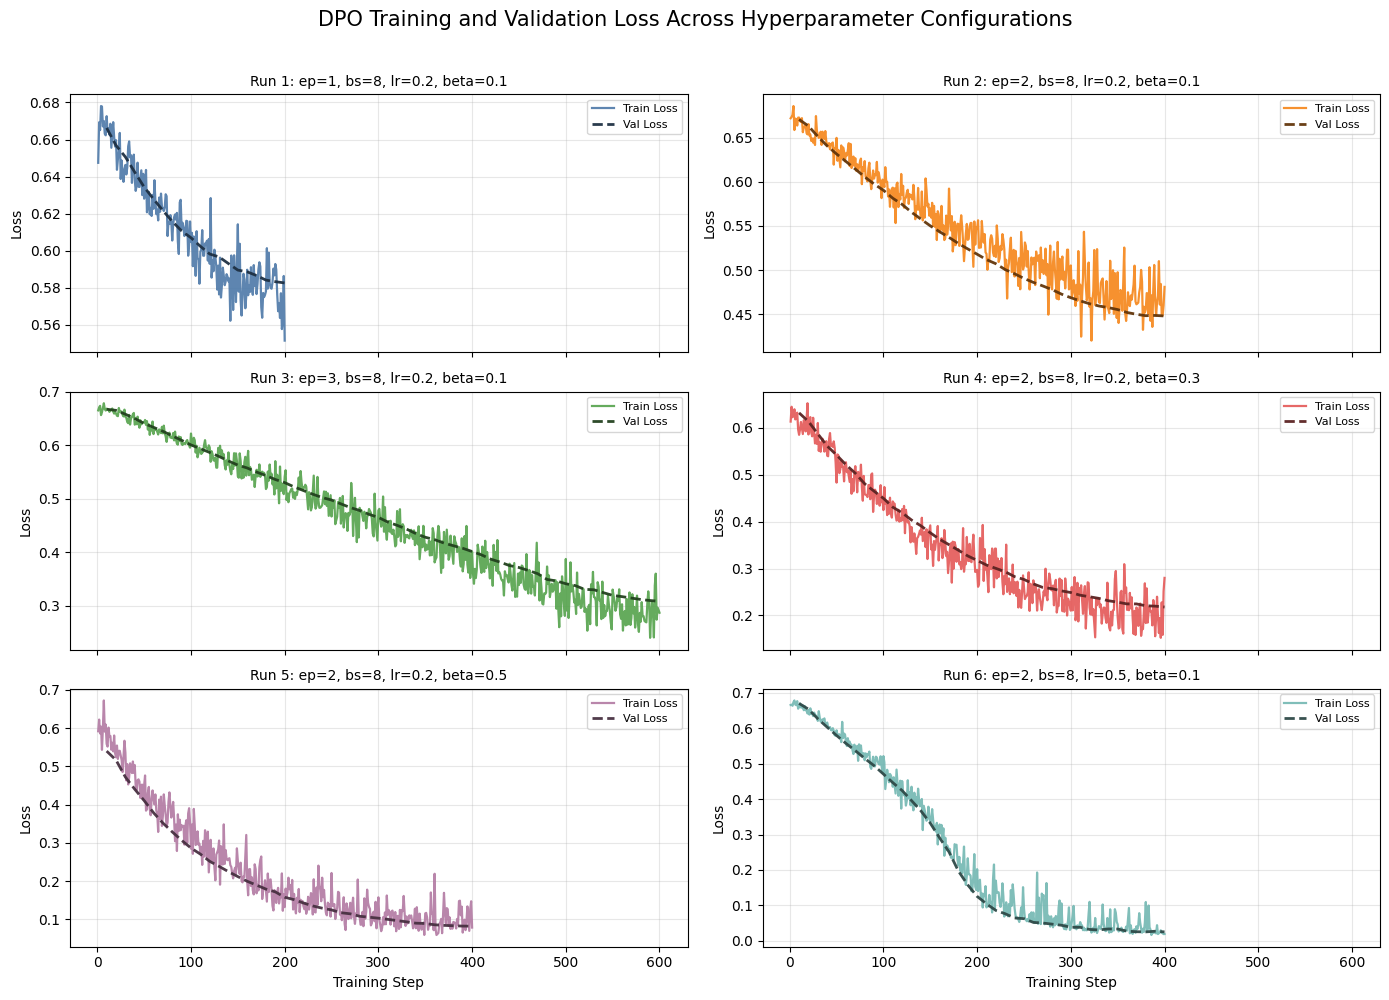

In [ ]:
# -----------------------------
# Train + Validation Loss
# 3 rows x 2 columns
# Legend inside each subplot
# Darker matching validation color
# -----------------------------

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# helper: darken color
def darken(color, factor=0.55):
    rgb = mcolors.to_rgb(color)
    return tuple(np.clip(np.array(rgb) * factor, 0, 1))

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(14, 10),
    sharex=True
)

axes = axes.flatten()

colors = [
    "#4C78A8",  # blue
    "#F58518",  # orange
    "#54A24B",  # green
    "#E45756",  # red
    "#B279A2",  # purple
    "#72B7B2",  # teal
]

for i, (ax, (name, df)) in enumerate(zip(axes, dfs.items())):

    train_color = colors[i]
    val_color = darken(train_color, factor=0.4)

    # training loss
    ax.plot(
        df["step"],
        df["train_loss"],
        color=train_color,
        linewidth=1.6,
        alpha=0.9,
        label="Train Loss"
    )

    # validation loss
    valid_df = df.dropna(subset=["valid_loss"])

    if len(valid_df) > 0:
        ax.plot(
            valid_df["step"],
            valid_df["valid_loss"],
            color=val_color,
            linewidth=2.0,
            linestyle="--",
            alpha=0.95,
            label="Val Loss"
        )

    ax.set_title(name, fontsize=10, pad=6)
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)

    # legend inside each subplot
    ax.legend(
        loc="upper right",
        fontsize=8,
        frameon=True
    )

# x labels only bottom row
for ax in axes[-2:]:
    ax.set_xlabel("Training Step")

fig.suptitle(
    "DPO Training and Validation Loss Across Hyperparameter Configurations",
    fontsize=15,
    y=0.995
)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig("dpo_train_val_loss_3x2_legends.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# -----------------------------
# 4. Final loss summary table
# -----------------------------

summary_rows = []

for name, df in dfs.items():
    final_train_loss = df["train_loss"].dropna().iloc[-1]

    valid_losses = df["valid_loss"].dropna()
    final_valid_loss = valid_losses.iloc[-1] if len(valid_losses) > 0 else np.nan

    full_valid_losses = df["full_valid_loss"].dropna()
    final_full_valid_loss = full_valid_losses.iloc[-1] if len(full_valid_losses) > 0 else np.nan

    summary_rows.append({
        "Run": name,
        "Final Train Loss": final_train_loss,
        "Final Valid Loss": final_valid_loss,
        "Final Full Valid Loss": final_full_valid_loss,
        "Num Steps": len(df)
    })

loss_summary = pd.DataFrame(summary_rows)
loss_summary

,Run,Final Train Loss,Final Valid Loss,Final Full Valid Loss,Num Steps
0,"Run 1: ep=1, bs=8, lr=0.2, beta=0.1",0.551447,0.582577,0.575803,200
1,"Run 2: ep=2, bs=8, lr=0.2, beta=0.1",0.481104,0.448246,0.463646,400
2,"Run 3: ep=3, bs=8, lr=0.2, beta=0.1",0.287246,0.308622,0.284714,600
3,"Run 4: ep=2, bs=8, lr=0.2, beta=0.3",0.280012,0.217876,0.203409,400
4,"Run 5: ep=2, bs=8, lr=0.2, beta=0.5",0.078816,0.082479,0.092802,400
5,"Run 6: ep=2, bs=8, lr=0.5, beta=0.1",0.019443,0.025453,0.035372,400


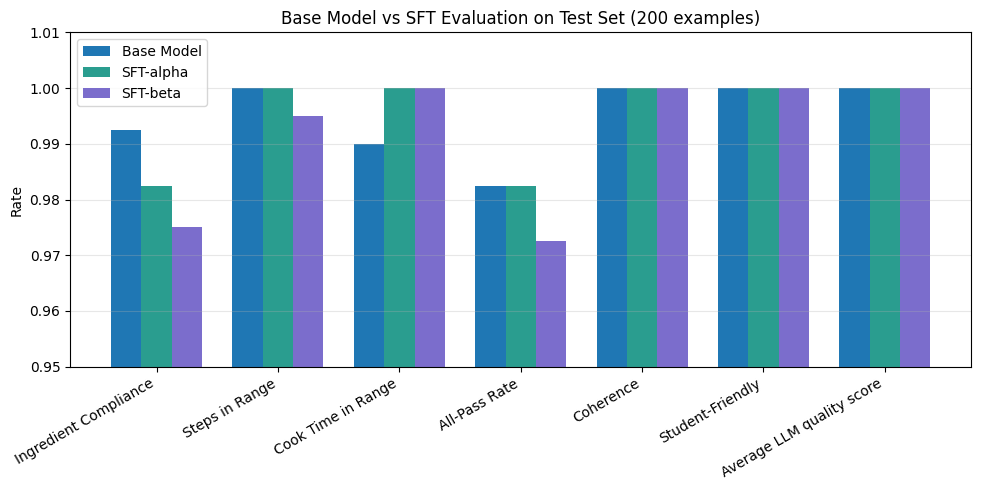

In [ ]:
# -----------------------------
# 5. Baseline vs SFT-alpha bar chart
# -----------------------------

metrics = [
    "Ingredient Compliance",
    "Steps in Range",
    "Cook Time in Range",
    "All-Pass Rate",
    "Coherence",
    "Student-Friendly",
    "Average LLM quality score"
]

base_values = [
    0.9925,
    1.0000,
    0.9900,
    0.9825,
    1.0000,
    1.0000,
    1.0000
]

sft_alpha_values = [
    0.9825,
    1.0000,
    1.0000,
    0.9825,
    1.0000,
    1.0000,
    1.0000
]

dpo_values = [
    0.9750,
    1.0000,
    0.9950,
    0.9700,
    0.9925,
    0.9975,
    0.9950
]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, base_values, width, label="Base Model", color="#1F77B4")
plt.bar(x, sft_alpha_values, width, label="SFT-alpha", color="#2A9D8F")
plt.bar(x + width, dpo_values, width, label="SFT-beta", color="#7B6DCC")

plt.ylabel("Rate")
plt.title("Base Model vs SFT Evaluation on Test Set (200 examples)")
plt.xticks(x, metrics, rotation=30, ha="right")
plt.ylim(0.95, 1.01)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("base_vs_sft_alpha_metrics.png", dpi=300)
plt.show()

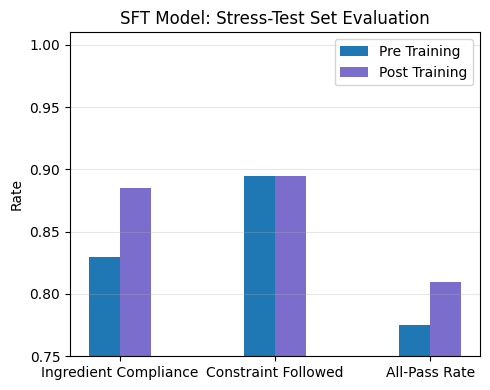

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

metrics = [
    "Ingredient Compliance",
    "Constraint Followed",
    "All-Pass Rate"
]

sft_before_train_values = [0.83, 0.895, 0.775]
sft_after_train_values  = [0.885, 0.895, 0.81]


x = np.arange(len(metrics))
width = 0.2   # wider bars

plt.figure(figsize=(5,4))  # smaller canvas

plt.bar(
    x - width/2,
    sft_before_train_values,
    width,
    label="Pre Training",
    color="#1F77B4"
)

plt.bar(
    x + width/2,
    sft_after_train_values,
    width,
    label="Post Training",
    color="#7B6DCC"
)

plt.ylabel("Rate")
plt.title("SFT Model: Stress-Test Set Evaluation")

plt.xticks(x, metrics)
plt.ylim(0.75, 1.01)   # tighter y-range reduces empty space

plt.legend(loc="upper right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()